In [40]:
# Import libraries (Python equivalent of R packages like dplyr, ggplot2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

In [41]:

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Rows in dataset:", len(raw_data))

Rows in dataset: 7214


In [42]:

print(raw_data.head())

   id                name   first         last compas_screening_date   sex  \
0   1    miguel hernandez  miguel    hernandez            2013-08-14  Male   
1   3         kevon dixon   kevon        dixon            2013-01-27  Male   
2   4            ed philo      ed        philo            2013-04-14  Male   
3   5         marcu brown   marcu        brown            2013-01-13  Male   
4   6  bouthy pierrelouis  bouthy  pierrelouis            2013-03-26  Male   

          dob  age          age_cat              race  ...  v_decile_score  \
0  1947-04-18   69  Greater than 45             Other  ...               1   
1  1982-01-22   34          25 - 45  African-American  ...               1   
2  1991-05-14   24     Less than 25  African-American  ...               3   
3  1993-01-21   23     Less than 25  African-American  ...               6   
4  1973-01-22   43          25 - 45             Other  ...               1   

   v_score_text  v_screening_date  in_custody  out_custody  pr

In [43]:
# Data Preprocessing and Feature Engineering (R → Python Translation)

# This step translates the R `dplyr` workflow into Python using pandas.
# Relevant columns are selected using DataFrame indexing, equivalent to `select()` in R.


df = raw_data[[
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "two_year_recid",
    "c_jail_in",
    "c_jail_out"
]].copy()

#Filtering conditions are applied using boolean indexing, replicating multiple `filter()` steps.
df = df[(df["days_b_screening_arrest"] >= -30) &
        (df["days_b_screening_arrest"] <= 30)]

df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]


# Datetime variables are converted using `pd.to_datetime()`, matching R’s `as.POSIXct()`.
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])



# New variables are created to mirror R’s `mutate()`:
# `crime_factor` replicates factor conversion of charge degree
# `age_factor` is created as a categorical variable with an ordered reference level
# `race_factor` and `gender_factor` replicate categorical transformations
# `score_factor` converts score_text into a binary categorical outcome (LowScore vs HighScore)
df["crime_factor"] = df["c_charge_degree"]

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

df["race_factor"] = pd.Categorical(df["race"])

df["gender_factor"] = df["sex"].replace({
    "Male": "Male",
    "Female": "Female"
})

df["score_factor"] = np.where(df["score_text"] == "Low",
                              "LowScore", "HighScore")


# The final row count is printed to verify that preprocessing matches the R output

print("Filtered rows:", len(df))

Filtered rows: 6172


In [44]:
df.head()

#This step replicates the `head(df)` function from R using `df.head()` in Python.

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [45]:
df.info()
#This step uses `df.info()` in Python to replicate the functionality of `glimpse(df)`

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

In [46]:
# Length of Stay and Correlation
#This step computes `length_of_stay` by taking the difference between `c_jail_out` and `c_jail_in` in days, replicating the R date subtraction.
# The correlation with `decile_score` is then calculated using `.corr()`, which is the Python equivalent of R’s `cor()`.
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

correlation = df["length_of_stay"].corr(df["decile_score"])
print("Correlation:", correlation)

Correlation: 0.20747808478031807


age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64
sex
Male      4997
Female    1175
Name: count, dtype: int64


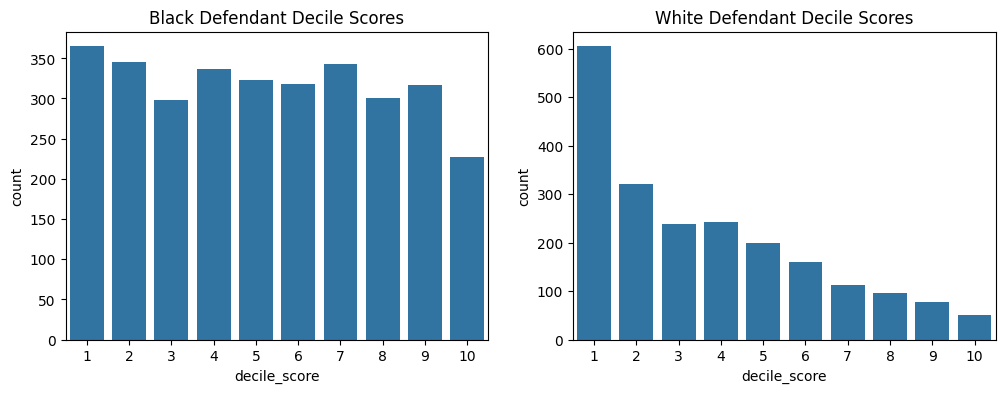

In [47]:

# Demographic Summaries and Visualization
#This step reproduces the R summary outputs using `value_counts()` in Python to display the distribution of age, race, and sex.
#Additionally, count plots are created using `seaborn` to visualize the distribution of decile scores by race.
#This corresponds to R’s use of summary tables and `ggplot2` visualizations, allowing for comparison of score distributions across demographic groups.
print(df["age_cat"].value_counts())
print(df["race"].value_counts())
print(df["sex"].value_counts())

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(data=df[df["race"]=="African-American"],
              x="decile_score",
              ax=axes[0])

axes[0].set_title("Black Defendant Decile Scores")

sns.countplot(data=df[df["race"]=="Caucasian"],
              x="decile_score",
              ax=axes[1])

axes[1].set_title("White Defendant Decile Scores")

plt.show()

In [48]:
# Logistic Regression and Evaluation
#Predicted probabilities are converted into binary class predictions using a 0.5 threshold.

df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

formula = """
score_binary ~ C(gender_factor, Treatment(reference='Male'))
             + C(age_factor, Treatment(reference='25 - 45'))
             + C(race_factor, Treatment(reference='Caucasian'))
             + priors_count
             + C(crime_factor)
             + two_year_recid
"""

#A binary target variable is created from `score_factor` (HighScore vs LowScore), and categorical predictors are specified with `C()` while explicitly setting reference categories to match the R model.


model = smf.logit(formula, data=df).fit()
print(model.summary())

df["pred_prob"] = model.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, 1, 0)
#Predicted probabilities are converted into binary class predictions using a 0.5 threshold.

# A confusion matrix and performance metrics are then computed to evaluate how well the model predicts COMPAS score classification.
cm = confusion_matrix(df["score_binary"], df["pred_class"])

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / cm.sum()
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("FPR:", fpr)
print("FNR:", fnr)


Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        16:11:45   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

In [49]:
# LOGIT Odds Ratio Interpretation
#This step translates the R calculation of predicted probabilities into Python to interpret the logistic regression coefficient.
#The baseline probability (`control`) is computed from the intercept, and the effect of the race coefficient is applied using the logistic transformation.
#The resulting value represents the odds ratio, showing how much more likely one group is to receive a higher score compared to the reference group, holding other variables constant.
import numpy as np

control = np.exp(-1.5255) / (1 + np.exp(-1.5255))

result = np.exp(0.4772) / (1 - control + (control * np.exp(0.4772)))

print(result)

1.452825407001621


In [50]:
# Gender Effect Interpretation
#This step applies the logistic transformation to the gender coefficient to compute the odds ratio.
# Using the baseline probability (`control`), the result quantifies how much more likely women are to receive a higher score compared to men, holding other variables constant.

result = np.exp(0.2213) / (1 - control + (control * np.exp(0.2213)))

print(result)

1.1948243807769987


In [51]:
# Age Effect Interpretation
#This step computes the odds ratio for individuals under 25 using the logistic transformation.
#Based on the model coefficient, the result indicates that individuals under 25 are significantly more likely to receive a higher score compared to the reference group (ages 25–45), holding other variables constant.

result = np.exp(1.3084) / (1 - control + (control * np.exp(1.3084)))

print(result)


2.496107351371129


In [52]:
# Predictions (equivalent to R mutate with predict + ifelse)

df["pred_prob"] = model.predict(df)

df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [53]:
# Overall Confusion Matrix and Model Evaluation

from sklearn.metrics import confusion_matrix

print("Overall Confusion Matrix")

cm = confusion_matrix(df["two_year_recid"], df["pred_class"] == "Recid")

print(cm)


TN, FP, FN, TP = cm.ravel()
n = cm.sum()

# The confusion matrix is  decomposed into:
# True Negatives (TN)
# False Positives (FP)
# False Negatives (FN)
# True Positives (TP)
accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)


# Using these values, key performance metrics are computed:
#  Accuracy: overall correctness of predictions
#  Precision: proportion of predicted positives that are correct
# Recall: proportion of actual positives correctly identified
#  FPR (False Positive Rate): rate of incorrect positive predictions
# FNR (False Negative Rate): rate of missed positive cases

print(f"\nAccuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"FPR      : {fpr:.3f}")
print(f"FNR      : {fnr:.3f}")

Overall Confusion Matrix
[[2653  710]
 [ 945 1864]]

Accuracy : 0.732
Precision: 0.724
Recall   : 0.664
FPR      : 0.211
FNR      : 0.336


In [54]:
print("Confusion Matrix by Race")

results = []

# The dataset is grouped by race, and for each group, actual outcomes and predicted
# classes are converted into binary values (0/1), matching R’s `as.integer()` logic.

for race, g in df.groupby("race"):
    actual = g["two_year_recid"].astype(int)
    pred = (g["pred_class"] == "Recid").astype(int)

    TP = ((pred == 1) & (actual == 1)).sum()
    TN = ((pred == 0) & (actual == 0)).sum()
    FP = ((pred == 1) & (actual == 0)).sum()
    FN = ((pred == 0) & (actual == 1)).sum()
    n = len(g)

    results.append({
        "race": race,
        "n": n,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": round((TP + TN) / n, 3),
        "Precision": round(TP / (TP + FP), 3) if (TP + FP) > 0 else 0,
        "Recall": round(TP / (TP + FN), 3) if (TP + FN) > 0 else 0,
        "FPR": round(FP / (FP + TN), 3) if (FP + TN) > 0 else 0,
        "FNR": round(FN / (FN + TP), 3) if (FN + TP) > 0 else 0
    })

race_metrics = pd.DataFrame(results).sort_values("n", ascending=False)

print(race_metrics)

Confusion Matrix by Race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [55]:
print("FPR and FNR Disparity by Race")


# First, the FPR and FNR values for the Caucasian group are extracted.
ref_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].values[0]
ref_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].values[0]

# Then, a new DataFrame is created with relevant columns.
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# For each race, the differences (delta_FPR and delta_FNR) are computed
# by subtracting the reference group's values, equivalent to R’s `mutate()` logic.


disparity["delta_FPR"] = (disparity["FPR"] - ref_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - ref_fnr).round(3)

print(disparity)

FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536
